# **Tutorial 09 - Parameter Estimation in ODE Models**: Supplementary Interactive Material

-------------------------------------------------------------------------

In Tutorial 08 the model was an explicit formula, so evaluating it at a trial parameter was free. Here the model is the *solution of an ODE*: every evaluation of the loss costs a numerical integration, which changes what a sensible fitting method looks like.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# Damped Harmonic Oscillator — Simulation and Parameter Estimation

The **damped harmonic oscillator** is a classical physical system that models many real-world processes such as springs with friction, electrical RLC circuits, and molecular vibrations.

The governing second-order ODE is:

$$
\frac{d^2x}{dt^2} + 2\zeta \omega \frac{dx}{dt} + \omega^2 x = 0 ,
$$

where  
- $x(t)$ = displacement,  
- $\zeta$ = damping ratio,  
- $\omega$ = natural frequency.

To solve numerically, we convert this into a **first-order system**:

$$
\begin{aligned}
\frac{dx}{dt} &= v \\
\frac{dv}{dt} &= -2\zeta\omega v - \omega^2 x
\end{aligned}
$$

---

### Objective

We follow these steps:

1. **Simulate the system** using known parameters $\zeta_{\text{true}}$ and $\omega_{\text{true}}$.
2. **Generate noisy observations** to mimic real experimental data.
3. **Estimate the parameters** $\zeta$ and $\omega$ by minimizing the **sum of squared errors** between the model and data (nonlinear least squares).
4. **Compare the fitted model to the true dynamics** visually.

The optimization problem is:

$$
\min_{\zeta, \omega} \quad 
\sum_{i} \left[ x_{\text{obs}}(t_i) - x_{\text{model}}(t_i; \zeta, \omega) \right]^2
$$

---

After simulating and fitting, we compare:
- **True model vs noisy data vs fitted model**  
- Evaluate how well the optimization recovered $(\zeta, \omega)$.

---
For this demonstration, we will try using Gradient descent.


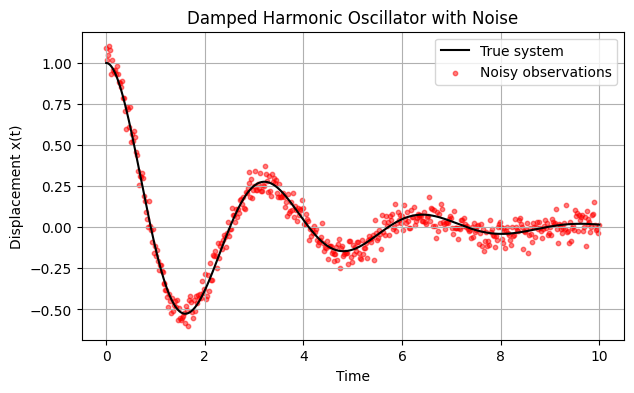

In [5]:

# ---- Damped harmonic oscillator ODE ----
def damped_oscillator(t, state, zeta, omega):
    x, v = state
    dxdt = v
    dvdt = -2 * zeta * omega * v - (omega**2) * x
    return [dxdt, dvdt]

# ---- True parameters ----
zeta_true = 0.2     # underdamped
omega_true = 2.0    # natural frequency
state0 = [1.0, 0.0] # initial displacement, zero velocity
t = np.linspace(0, 10, 500)

# ---- Simulate ----
solution = solve_ivp(lambda t, y: damped_oscillator(t, y, zeta_true, omega_true),
                     (t[0], t[-1]), state0, t_eval=t)

x_true = solution.y[0]

# ---- Add noisy synthetic observations ----
np.random.seed(0)
noise_level = 0.05
x_obs = x_true + noise_level * np.random.randn(len(x_true))

plt.figure(figsize=(7,4))
plt.plot(t, x_true, 'k-', label='True system')
plt.scatter(t, x_obs, s=10, color='red', alpha=0.5, label='Noisy observations')
plt.xlabel('Time')
plt.ylabel('Displacement x(t)')
plt.title('Damped Harmonic Oscillator with Noise')
plt.legend()
plt.grid(True)
plt.show()


In [6]:

# Loss function (SSE between model and observed data)
def loss(zeta, omega):
    sol = solve_ivp(lambda t, y: damped_oscillator(t, y, zeta, omega),
                    (t[0], t[-1]), state0, t_eval=t)
    x_model = sol.y[0]
    return np.sum((x_model - x_obs)**2)

# Numerical gradients dL/dzeta and dL/domega
def grad(zeta, omega, h=1e-4):
    L = loss(zeta, omega)
    dL_dzeta = (loss(zeta + h, omega) - L) / h
    dL_domega = (loss(zeta, omega + h) - L) / h
    return dL_dzeta, dL_domega

# --- Gradient Descent Loop ---
zeta_gd, omega_gd = 0.5, 1.0    # initial guesses
lr = 1e-3                       # learning rate
history = []

for i in range(100):            # 100 iterations max
    dLz, dLw = grad(zeta_gd, omega_gd)
    zeta_gd -= lr * dLz
    omega_gd -= lr * dLw

    L = loss(zeta_gd, omega_gd)
    history.append(L)

    if i % 10 == 0:
        print(f"Iter {i:2d} | ζ = {zeta_gd:.4f}, ω = {omega_gd:.4f}, Loss = {L:.6f}")

print("\nFinal parameters (Gradient Descent):")
print(f"ζ ≈ {zeta_gd:.4f}, ω ≈ {omega_gd:.4f}")

Iter  0 | ζ = 0.4942, ω = 1.0731, Loss = 50.332836
Iter 10 | ζ = 0.3390, ω = 1.6383, Loss = 15.800818
Iter 20 | ζ = 0.1964, ω = 1.9637, Loss = 1.471335
Iter 30 | ζ = 0.1993, ω = 2.0073, Loss = 1.232486
Iter 40 | ζ = 0.1999, ω = 2.0123, Loss = 1.229347
Iter 50 | ζ = 0.2000, ω = 2.0129, Loss = 1.229285
Iter 60 | ζ = 0.2000, ω = 2.0130, Loss = 1.229283
Iter 70 | ζ = 0.2000, ω = 2.0130, Loss = 1.229283
Iter 80 | ζ = 0.2000, ω = 2.0130, Loss = 1.229283
Iter 90 | ζ = 0.2000, ω = 2.0130, Loss = 1.229283

Final parameters (Gradient Descent):
ζ ≈ 0.2000, ω ≈ 2.0130


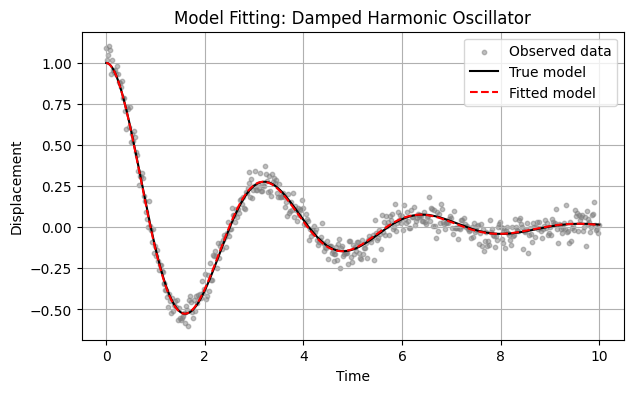

In [7]:
# Re-simulate using fitted parameters
sol_fit = solve_ivp(lambda t, y: damped_oscillator(t, y, zeta_gd, omega_gd),
                    (t[0], t[-1]), state0, t_eval=t)

x_fit = sol_fit.y[0]

plt.figure(figsize=(7,4))
plt.scatter(t, x_obs, s=10, color='gray', alpha=0.5, label='Observed data')
plt.plot(t, x_true, 'k-', label='True model')
plt.plot(t, x_fit, 'r--', label='Fitted model')
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.title('Model Fitting: Damped Harmonic Oscillator')
plt.legend()
plt.grid(True)
plt.show()


**While Gradient Descent proved successful here:** 

It often isn’t ideal for ODE parameter estimation because:
- Each step requires solving the ODE — it becomes slow.
- The loss surface is often non-convex — GD can get stuck.
- Choosing a learning rate that works is often a process of trial and error.

So GD works as a **demonstration**, but for real problems we use more reliable methods like Levenberg–Marquardt, trust-region solvers, or global methods like simulated annealing.